# [Step 1] 대리 모델(Surrogate)을 통한 데이터 증강 — v2 (Improved)

> **목표:** ~900개의 생존 시뮬레이션 데이터에서 300초 시계열의 **'절댓값 Max Peak(부호 유지)'**를 추출하고,  
> XGBoost 대리 모델을 학습하여 **10만 개의 가상 P1~P6 조합**에 대한 응력/변형 결과를 예측합니다.

---

### v2 개선 사항
| 항목 | v1 (기존) | v2 (개선) |
|------|-----------|----------|
| 마스터 매칭 | Row_ID 컬럼 의존 | 행 인덱스 기반 자동 매칭 (실제 DOE 구조 반영) |
| 모델 학습 | MultiOutputRegressor 래핑 | **타겟별 개별 XGBoost** (하이퍼파라미터 독립 튜닝 가능) |
| 검증 | 단순 Train/Test Split | **5-Fold CV** + 홀드아웃 테스트 병행 |
| EDA | 없음 | 피크 분포, 상관관계 히트맵, Pred vs Actual 산점도 |
| 이상치 검증 | 없음 | 예측된 가상 데이터의 물리적 범위 이탈 경고 |
| 난수 생성 | 균일분포 | **Latin Hypercube Sampling (LHS)** 옵션 추가 |
| 주석 | 최소 | 모든 셀 상세 주석 |

---

### 핵심 물리 로직: '절댓값 Max Peak' 추출
열 사이클링에서 응력은 가열 시 (+), 냉각 시 (-) 방향으로 진동합니다.  
**단순 max()를 쓰면 냉각 시 압축 응력(음수)의 위험성을 놓칩니다.**  
따라서 `abs().idxmax()`로 절댓값이 가장 큰 시점을 찾되, 그 시점의 **원래 부호를 보존**합니다.

```python
# 절댓값이 가장 큰 시점의 인덱스 -> 해당 시점의 원본 값(부호 유지)
max_abs_idx = df_time[col].abs().idxmax()
peak_value  = df_time.loc[max_abs_idx, col]   # 예: -30 (압축 피크)
```

---
## 0. 환경 설정 및 라이브러리 로드

In [4]:
import os
import re
import glob
import time
import warnings
import platform  # OS 자동 감지용 모듈 추가
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')  # XGBoost deprecation 경고 억제
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 9

# ====================================================================
# [경로 자동 설정] Windows와 WSL(Linux) 환경을 자동 감지하여 경로 할당
# ====================================================================
if platform.system() == 'Linux':
    # WSL (리눅스) 환경일 경우 마운트 경로 사용
    CSV_FOLDER = '/mnt/i/ai_model_dev/cfd/SIM_CSV_DATA'
    MASTER_CSV = '/mnt/i/ai_model_dev/cfd/Master_DOE_1200.csv'
else:
    # Windows 데스크탑 환경일 경우
    CSV_FOLDER = r'I:\ai_model_dev\cfd\SIM_CSV_DATA'
    MASTER_CSV = r'I:\ai_model_dev\cfd\Master_DOE_1200.csv' # 안정성을 위해 절대경로로 통일

# 추출 대상 Y 변수 15개 (Time, TempBase 제외)
# 각 변수의 물리적 의미를 주석으로 명시
Y_COLUMNS = [
    'WarpMax',          # 패키지 전체 최대 열변형량 (최소화 메인 타겟 #1)
    'T_Tip_Peel',       # Top 계면 끝단 수직응력 - 박리(Delamination) 원인 (최소화 메인 타겟 #2)
    'T_Tip_Shear',      # Top 계면 끝단 전단응력 - 계면 피로(Fatigue) 유발
    'T_Tip_SEQV',       # Top 끝단 Von Mises 등가응력 - 소성 변형 유발
    'T_Tip_Strain',     # Top 끝단 변형률
    'T_Avg_Peel',       # Top 접합면 평균 수직응력 - 중앙부 Void 유발
    'T_Avg_Shear',      # Top 접합면 평균 전단응력
    'B_Tip_Peel',       # Bottom 끝단 수직응력
    'B_Tip_Shear',      # Bottom 끝단 전단응력
    'B_Tip_SEQV',       # Bottom 끝단 Von Mises 등가응력
    'B_Tip_Strain',     # Bottom 끝단 변형률
    'B_Avg_Peel',       # Bottom 평균 수직응력
    'B_Avg_Shear',      # Bottom 평균 전단응력
    'Die_SX',           # 다이(실리콘 칩) 휨 응력 - Die Crack 유발
    'Die_SY_Max'        # 다이 최대 Y방향 응력 - 모서리 응력 집중
]

# 난수 시드 (재현성 보장)
SEED = 42
np.random.seed(SEED)

print('=== 환경 설정 완료 ===')
print(f'현재 감지된 OS: {platform.system()}')
print(f'시계열 CSV 폴더 : {CSV_FOLDER}')
print(f'마스터 DOE 파일 : {MASTER_CSV}')
print(f'추출 대상 Y 변수: {len(Y_COLUMNS)}개')

=== 환경 설정 완료 ===
현재 감지된 OS: Linux
시계열 CSV 폴더 : /mnt/i/ai_model_dev/cfd/SIM_CSV_DATA
마스터 DOE 파일 : /mnt/i/ai_model_dev/cfd/Master_DOE_1200.csv
추출 대상 Y 변수: 15개


---
## 1. 마스터 DOE 로드 및 생존 CSV 탐지

**데이터 구조 (확인 완료):**
- `Master_DOE_1200.csv`: P1~P6 컬럼만 존재 (Row_ID 없음, 1200행)
  - 행 인덱스(0-based) + 1 = Row_ID로 매핑
  - P1: [0.80, 1.10] / P2: [0.05, 0.09] / P3: [0.60, 0.72]
  - P4: [0.10, 0.30] / P5: [1.20, 1.80] / P6: [0.04, 0.08]
- 시계열 파일: `ML_DATA_Extract_Row_{Row_ID}.csv` (617행 x 17열, 0.1~300초)

In [5]:
# == 1-1. 마스터 DOE 로드 ==
# P1~P6만 존재하는 1200행 파일. Row_ID 컬럼이 없으므로 직접 부여함.
df_master = pd.read_csv(MASTER_CSV)

# Row_ID 생성: 행 인덱스 + 1 = CSV 파일명의 Row 번호와 1:1 대응
# 즉, Master CSV의 1번째 행(index=0) -> Row_ID=1 -> ML_DATA_Extract_Row_1.csv
df_master.insert(0, 'Row_ID', range(1, len(df_master) + 1))

print(f'마스터 DOE 로드 완료: {len(df_master)}개 DP (Design Points)')
print(f'컬럼: {list(df_master.columns)}')
print()

# 각 P 변수의 범위 확인 (몬테카를로 생성 시 바운더리로 사용됨)
print('-- P1~P6 실제 범위 --')
for col in ['P1','P2','P3','P4','P5','P6']:
    print(f'  {col}: [{df_master[col].min():.4f}, {df_master[col].max():.4f}]')

display(df_master.head())

마스터 DOE 로드 완료: 1200개 DP (Design Points)
컬럼: ['Row_ID', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6']

-- P1~P6 실제 범위 --
  P1: [0.8005, 1.0998]
  P2: [0.0500, 0.0899]
  P3: [0.6001, 0.7198]
  P4: [0.1000, 0.2994]
  P5: [1.2003, 1.7997]
  P6: [0.0401, 0.0800]


,Row_ID,P1,P2,P3,P4,P5,P6
0,1,0.8317,0.0842,0.6021,0.1075,1.7454,0.0585
1,2,0.8143,0.0777,0.7136,0.1333,1.4174,0.0696
2,3,0.8013,0.0512,0.6363,0.2312,1.3751,0.0560
3,4,1.0509,0.0569,0.6031,0.2220,1.2660,0.0777
4,5,0.8744,0.0670,0.6206,0.2669,1.4158,0.0779


In [6]:
# == 1-2. 생존 CSV 파일 자동 탐지 ==
# 폴더를 스캔하여 실제 존재하는 시계열 파일의 Row_ID를 파싱
# (시뮬레이션이 터진 DP는 CSV 파일 자체가 생성되지 않음)

# glob으로 해당 폴더의 모든 ML_DATA_Extract_Row_*.csv 파일 탐색
pattern = os.path.join(CSV_FOLDER, 'ML_DATA_Extract_Row_*.csv')
found_files = sorted(glob.glob(pattern))

# 파일명에서 Row_ID 숫자를 정규식으로 추출
survived_ids = []
for fpath in found_files:
    fname = os.path.basename(fpath)
    match = re.search(r'Row_(\d+)\.csv', fname)
    if match:
        survived_ids.append(int(match.group(1)))

survived_ids = sorted(survived_ids)

# 전체 DP 수 = 폴더 내 가장 큰 Row_ID (실제 시뮬레이션이 시도된 총 수)
n_total = max(survived_ids)
n_alive = len(survived_ids)
n_dead  = n_total - n_alive

print(f'전체 DP      : {n_total}개 (최대 Row_ID 기준)')
print(f'생존 CSV     : {n_alive}개 ({n_alive/n_total*100:.1f}%)')
print(f'결측(터진) DP: {n_dead}개 ({n_dead/n_total*100:.1f}%)')
print(f'생존 Row_ID 범위: {min(survived_ids)} ~ {max(survived_ids)}')

전체 DP      : 856개 (최대 Row_ID 기준)
생존 CSV     : 629개 (73.5%)
결측(터진) DP: 227개 (26.5%)
생존 Row_ID 범위: 1 ~ 856


---
## 2. 시계열 데이터에서 '절댓값 Max Peak' 추출 (Feature Extraction)

각 생존 CSV(300초, 617 timestep)에서 15개 Y 채널별로:
1. `abs().idxmax()` -> 절댓값이 최대인 시간 인덱스 탐색
2. 해당 시점의 원본 값(부호 유지)을 피크로 기록

결과: **[Row_ID, P1~P6, Y1_peak ~ Y15_peak]** 형태의 정적 데이터셋 구축

In [7]:
# == 2-1. 생존 데이터 순회 및 Max Peak 추출 ==

valid_data = []     # 정상 추출된 데이터를 누적할 리스트
error_rows = []     # 읽기 오류가 발생한 Row_ID를 기록할 리스트

t_start = time.time()
print(f'{len(survived_ids)}개 생존 CSV에서 Max Peak 추출 시작...')

for i, row_id in enumerate(survived_ids):
    # 시계열 CSV 파일 경로 구성
    fpath = os.path.join(CSV_FOLDER, f'ML_DATA_Extract_Row_{row_id}.csv')
    
    try:
        # 시계열 데이터 로드 (617행 x 17열: Time, TempBase, 15 Y변수)
        df_ts = pd.read_csv(fpath)
        
        # 컬럼명 앞뒤 공백 제거 (CSV 헤더에 공백 포함될 수 있음)
        df_ts.columns = [c.strip() for c in df_ts.columns]
        
        # 마스터 DOE에서 해당 Row의 P1~P6 가져오기
        # Row_ID는 1-based이므로, df_master에서 Row_ID == row_id인 행을 찾음
        master_row = df_master[df_master['Row_ID'] == row_id]
        if master_row.empty:
            error_rows.append((row_id, 'Master DOE에 해당 Row_ID 없음'))
            continue
        
        # 결과 딕셔너리 초기화
        peak_dict = {'Row_ID': row_id}
        
        # P1~P6 설계변수 값 저장
        for p_col in ['P1','P2','P3','P4','P5','P6']:
            peak_dict[p_col] = master_row[p_col].values[0]
        
        # === 핵심 로직: 각 Y 채널별 '절댓값 최대 피크(부호 유지)' 추출 ===
        for y_col in Y_COLUMNS:
            if y_col in df_ts.columns:
                # Step A: 300초 시계열에서 절댓값이 가장 큰 시간 인덱스 탐색
                #   abs()로 절댓값을 취한 뒤 idxmax()로 최대 위치를 찾음
                max_abs_idx = df_ts[y_col].abs().idxmax()
                
                # Step B: 해당 시점의 원래 값(부호 보존)을 피크로 기록
                #   예) 시계열이 [+10, -30, +20]이면:
                #       abs = [10, 30, 20] -> idxmax = 1 -> 원본값 = -30
                #   이렇게 해야 냉각 시 압축 응력의 위험성을 놓치지 않음
                peak_dict[y_col] = df_ts.loc[max_abs_idx, y_col]
            else:
                # 해당 Y 컬럼이 CSV에 없는 경우 NaN 처리
                peak_dict[y_col] = np.nan
        
        valid_data.append(peak_dict)
        
    except Exception as e:
        error_rows.append((row_id, str(e)))
    
    # 진행률 표시 (200개마다)
    if (i + 1) % 200 == 0:
        print(f'  ... {i+1}/{len(survived_ids)} 처리 완료')

elapsed = time.time() - t_start

# 결과 취합
df_peaks = pd.DataFrame(valid_data)

print(f'\n=== Max Peak 추출 완료 ===')
print(f'성공: {len(df_peaks)}개 / 실패: {len(error_rows)}개 / 소요시간: {elapsed:.1f}초')

if error_rows:
    print(f'\n[경고] 오류 발생 Row (처음 5개): {error_rows[:5]}')

# NaN이 있는 행 확인 및 제거
nan_count = df_peaks[Y_COLUMNS].isnull().any(axis=1).sum()
if nan_count > 0:
    print(f'[경고] {nan_count}개 행에 NaN 존재 -> 해당 행 제거')
    df_peaks = df_peaks.dropna(subset=Y_COLUMNS).reset_index(drop=True)

print(f'\n최종 학습용 데이터: {len(df_peaks)}개')
display(df_peaks.head())

629개 생존 CSV에서 Max Peak 추출 시작...
  ... 200/629 처리 완료
  ... 400/629 처리 완료
  ... 600/629 처리 완료

=== Max Peak 추출 완료 ===
성공: 629개 / 실패: 0개 / 소요시간: 9.3초

최종 학습용 데이터: 629개


,Row_ID,P1,P2,P3,P4,P5,P6,WarpMax,T_Tip_Peel,T_Tip_Shear,...,T_Avg_Peel,T_Avg_Shear,B_Tip_Peel,B_Tip_Shear,B_Tip_SEQV,B_Tip_Strain,B_Avg_Peel,B_Avg_Shear,Die_SX,Die_SY_Max
0,1,0.8317,0.0842,0.6021,0.1075,1.7454,0.0585,-0.107084,-34.039048,-8.025589,...,0.023255,-3.071933,-5.445917,-2.957903,28.329506,0.002043,0.032548,-2.861042,66.203874,-85.012494
1,2,0.8143,0.0777,0.7136,0.1333,1.4174,0.0696,-0.144790,-31.629051,8.315480,...,0.031333,-2.707141,-4.092614,-2.676881,25.607135,0.001761,0.025406,-2.568996,63.021576,-87.551451
2,4,1.0509,0.0569,0.6031,0.2220,1.2660,0.0777,-0.158005,-38.879585,8.994357,...,0.084601,-2.668019,-4.944124,-2.822713,29.147154,0.001970,-0.027274,-2.938019,61.316208,-86.130069
3,5,0.8744,0.0670,0.6206,0.2669,1.4158,0.0779,-0.138039,-33.084874,8.631955,...,0.031446,-2.621313,-4.015564,-2.296843,26.291782,0.001684,-0.015385,-2.606656,58.891827,-81.062810
4,7,0.9347,0.0506,0.6789,0.1163,1.6356,0.0661,-0.120482,-41.494301,8.232958,...,0.081118,-2.695119,-5.653280,-2.729163,32.351288,0.002114,0.010124,-2.795657,58.882464,-89.189848


---
## 3. 탐색적 데이터 분석 (EDA)

학습 전 데이터의 분포와 상관관계를 시각화하여 이상 패턴을 사전 진단합니다.

In [8]:
# == 3-1. Y 변수 기술 통계 ==
print('=== Y 변수 기술 통계 (Max Peak 기준) ===')
display(df_peaks[Y_COLUMNS].describe().round(4))

=== Y 변수 기술 통계 (Max Peak 기준) ===


,WarpMax,T_Tip_Peel,T_Tip_Shear,T_Tip_SEQV,T_Tip_Strain,T_Avg_Peel,T_Avg_Shear,B_Tip_Peel,B_Tip_Shear,B_Tip_SEQV,B_Tip_Strain,B_Avg_Peel,B_Avg_Shear,Die_SX,Die_SY_Max
count,629.0000,629.0000,629.0000,629.0000,629.0000,629.0000,629.0000,629.0000,629.0000,629.0000,629.0000,629.0000,629.0000,629.0000,629.0000
mean,-0.1363,-35.4222,7.6154,38.1007,0.0035,0.0315,-2.8816,-5.8545,-2.7560,28.3837,0.0020,-0.0024,-2.8793,62.5343,-88.1885
std,0.0183,2.8946,4.3884,3.4823,0.0003,0.0303,0.3333,2.1837,0.4919,2.0058,0.0002,0.0199,0.3011,4.0683,5.6749
min,-0.1728,-47.2917,-13.0566,30.9377,0.0028,-0.0317,-5.2160,-12.5674,-6.0878,23.2101,0.0015,-0.0677,-5.2635,57.7090,-104.0513
25%,-0.1511,-37.2888,8.1801,35.7014,0.0033,0.0107,-2.9895,-7.0606,-3.0411,26.9465,0.0018,-0.0166,-2.9794,59.7285,-92.5169
50%,-0.1359,-35.3591,8.6319,37.7992,0.0035,0.0263,-2.7994,-5.7806,-2.7136,28.2074,0.0020,-0.0046,-2.8195,61.1587,-87.7754
75%,-0.1210,-33.2754,9.0466,39.9126,0.0037,0.0555,-2.6859,-4.7692,-2.4265,29.5922,0.0021,0.0137,-2.6844,64.3108,-84.1699
max,-0.1025,-28.7603,10.6679,56.8349,0.0049,0.1454,-2.4083,11.6636,-1.6600,38.1656,0.0031,0.0407,-2.3874,87.9883,-72.2885


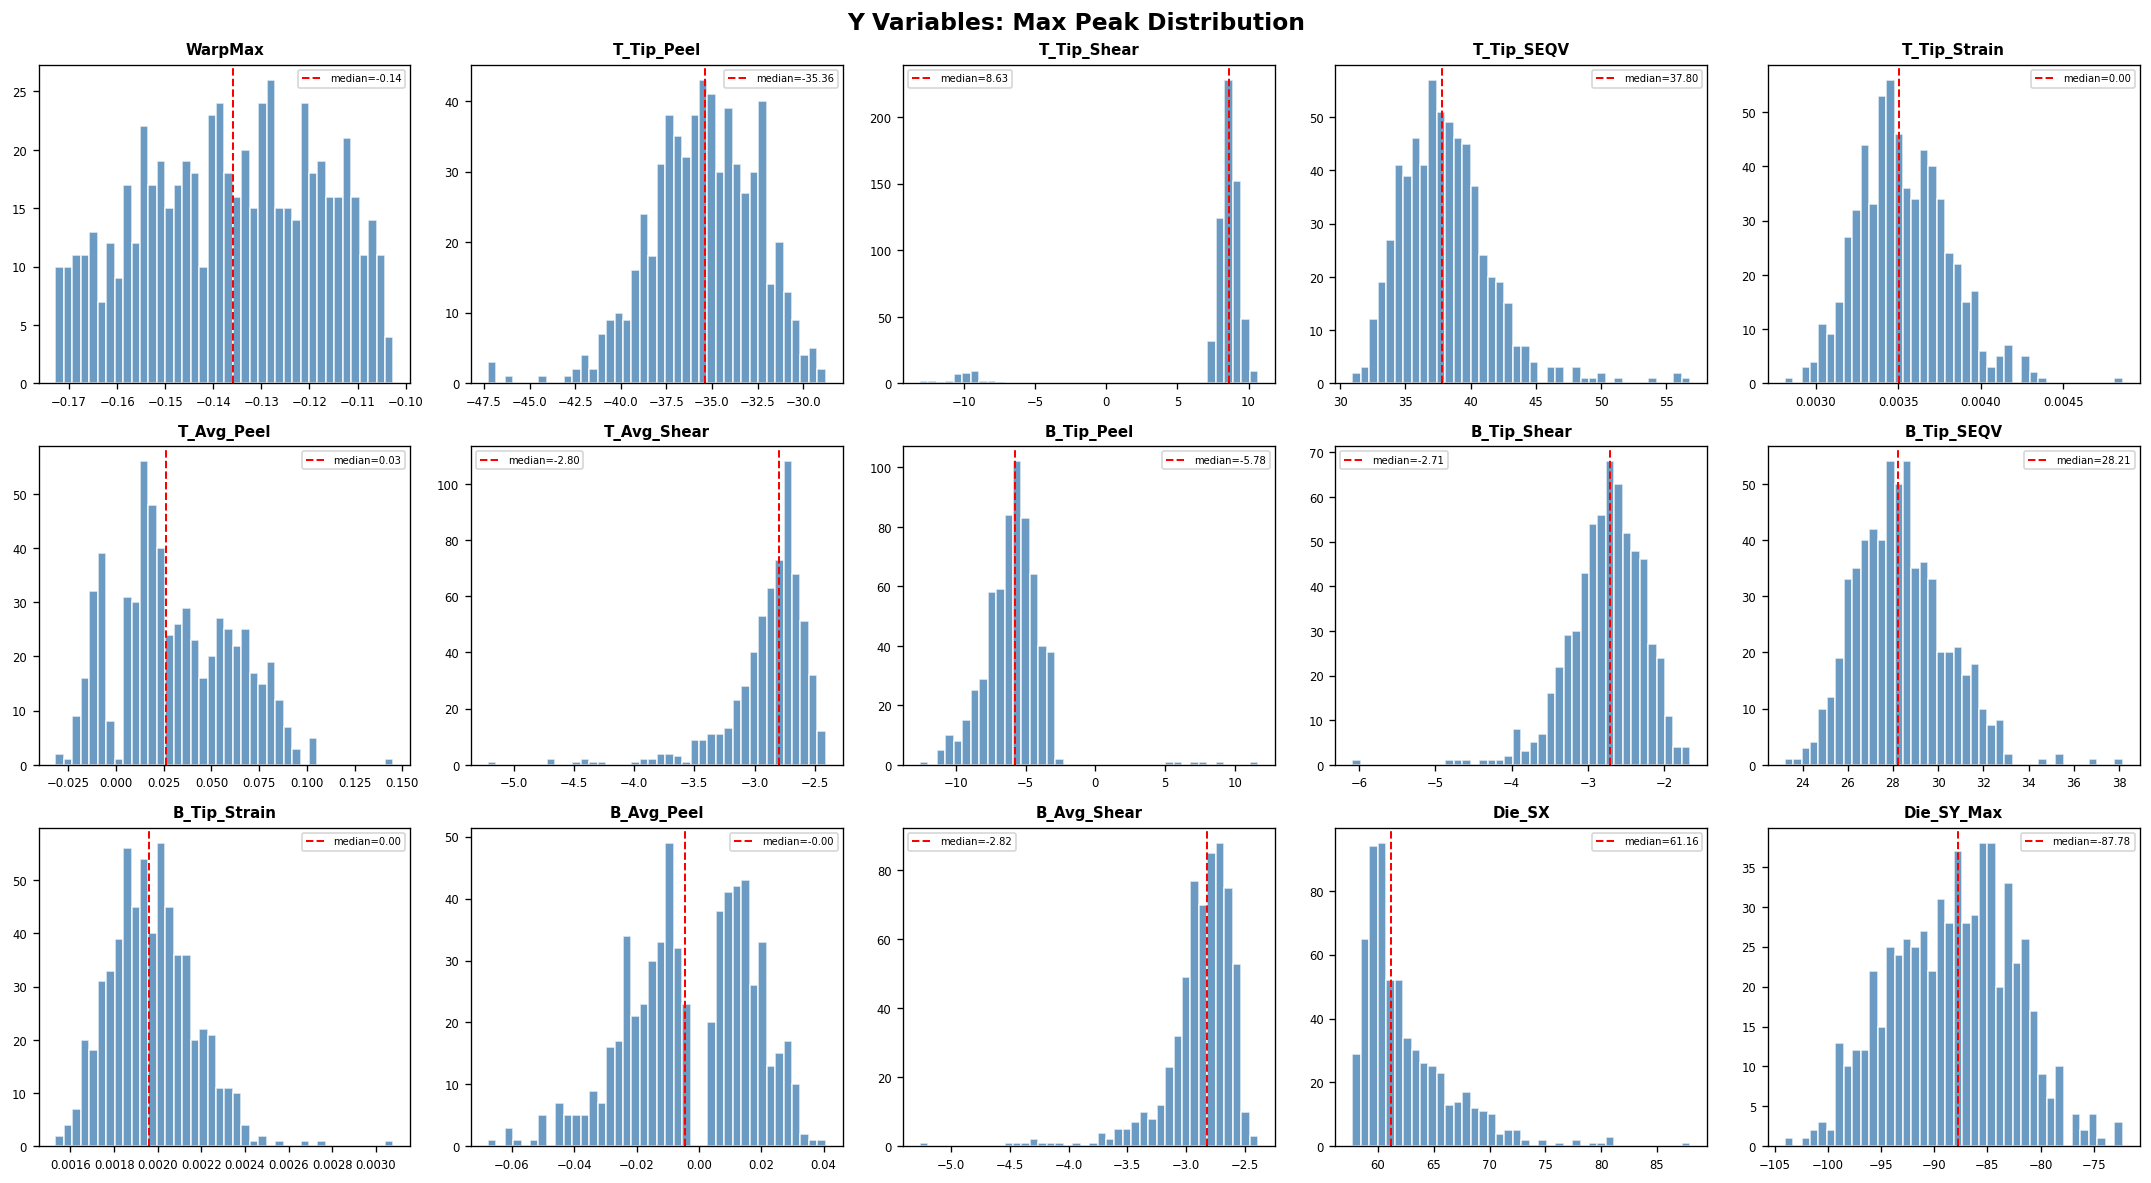

In [9]:
# == 3-2. Y 변수 피크값 분포 히스토그램 ==
# 각 응력/변형 채널의 피크 분포를 확인하여 편향(skew)이나 이상치 진단

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
fig.suptitle('Y Variables: Max Peak Distribution', fontsize=14, fontweight='bold')

for idx, y_col in enumerate(Y_COLUMNS):
    ax = axes[idx // 5, idx % 5]
    data = df_peaks[y_col].dropna()
    
    # 히스토그램 + 중앙값 표시
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(data.median(), color='red', linewidth=1.2, linestyle='--',
               label=f'median={data.median():.2f}')
    ax.set_title(y_col, fontsize=9, fontweight='bold')
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

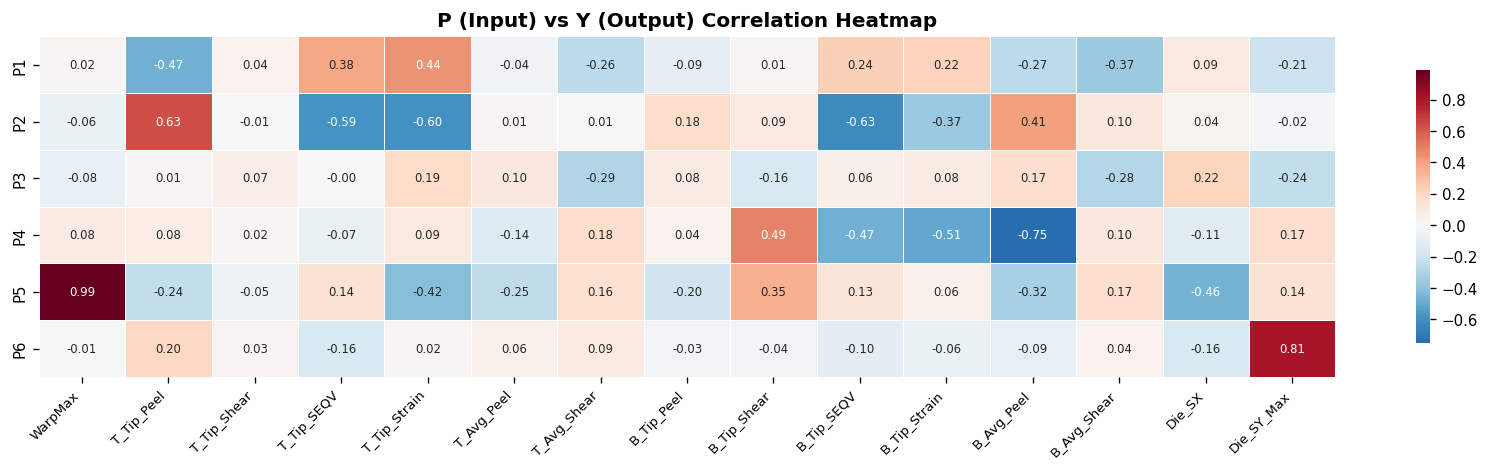


-- |상관계수| > 0.5인 강한 P-Y 관계 --
  P2 -> T_Tip_Peel: r=0.631 (양의 상관)
  P2 -> T_Tip_SEQV: r=-0.586 (음의 상관)
  P2 -> T_Tip_Strain: r=-0.597 (음의 상관)
  P2 -> B_Tip_SEQV: r=-0.626 (음의 상관)
  P4 -> B_Tip_Strain: r=-0.509 (음의 상관)
  P4 -> B_Avg_Peel: r=-0.750 (음의 상관)
  P5 -> WarpMax: r=0.987 (양의 상관)
  P6 -> Die_SY_Max: r=0.814 (양의 상관)


In [10]:
# == 3-3. P(입력) <-> Y(출력) 상관관계 히트맵 ==
# 어떤 두께 변수(P)가 어떤 응력(Y)에 강하게 영향을 미치는지 파악

p_cols = ['P1','P2','P3','P4','P5','P6']
corr_matrix = df_peaks[p_cols + Y_COLUMNS].corr()

# P vs Y 영역만 추출 (6 x 15 부분행렬)
corr_py = corr_matrix.loc[p_cols, Y_COLUMNS]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(corr_py, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 7},
            cbar_kws={'shrink': 0.8})
ax.set_title('P (Input) vs Y (Output) Correlation Heatmap', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

# 상관관계가 강한 P-Y 조합 출력 (|r| > 0.5)
print('\n-- |상관계수| > 0.5인 강한 P-Y 관계 --')
for p in p_cols:
    for y in Y_COLUMNS:
        r = corr_py.loc[p, y]
        if abs(r) > 0.5:
            direction = '양' if r > 0 else '음'
            print(f'  {p} -> {y}: r={r:.3f} ({direction}의 상관)')

---
## 4. XGBoost 대리 모델 학습

### 학습 전략
- **타겟별 개별 XGBoost** 학습 (각 타겟의 하이퍼파라미터를 독립 튜닝 가능)
- **5-Fold Cross Validation**으로 과적합 여부 진단
- **홀드아웃 Test Set (15%)**으로 최종 성능 평가
- **Early Stopping**: validation loss가 20 라운드 연속 개선 안 되면 조기 종료

### 하이퍼파라미터 선정 근거
- `n_estimators=300`: ~900개 중간 규모 데이터에 충분한 앙상블 수
- `max_depth=6`: 6개 입력변수 대비 적절한 트리 깊이
- `learning_rate=0.05`: 보수적 학습률로 과적합 방지
- `subsample/colsample_bytree=0.8`: 랜덤 서브샘플링으로 일반화 향상
- `reg_alpha=0.1, reg_lambda=1.0`: L1/L2 정규화로 복잡도 억제

In [11]:
# == 4-1. X / Y 분리 및 Train / Test Split ==

X = df_peaks[['P1','P2','P3','P4','P5','P6']].copy()  # 입력: 6개 두께 변수
Y = df_peaks[Y_COLUMNS].copy()                         # 출력: 15개 응력/변형 피크

# 홀드아웃 테스트셋 15% 분리 (최종 성능 평가용, 학습에 절대 사용 안 함)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.15, random_state=SEED
)

# Early Stopping을 위한 Validation Set 추가 분리 (Train의 15%)
X_tr, X_val, Y_tr, Y_val = train_test_split(
    X_train, Y_train, test_size=0.15, random_state=SEED
)

print(f'전체 데이터: {len(X)}개')
print(f'  +-- Train : {len(X_tr)}개 (XGBoost 학습)')
print(f'  +-- Val   : {len(X_val)}개 (Early Stopping 모니터링)')
print(f'  +-- Test  : {len(X_test)}개 (최종 성능 평가, 학습에 미사용)')

전체 데이터: 629개
  +-- Train : 453개 (XGBoost 학습)
  +-- Val   : 81개 (Early Stopping 모니터링)
  +-- Test  : 95개 (최종 성능 평가, 학습에 미사용)


In [12]:
# == 4-2. 타겟별 개별 XGBoost 학습 ==
# 15개 Y 변수 각각에 대해 독립적인 XGBoost 모델을 학습
# (MultiOutputRegressor 대비 장점: 타겟별 하이퍼파라미터 독립 조정 가능)

# 공통 하이퍼파라미터 설정
XGB_PARAMS = dict(
    n_estimators=300,           # 최대 부스팅 라운드 수
    learning_rate=0.05,         # 보수적 학습률 (과적합 방지)
    max_depth=6,                # 트리 깊이 (입력변수 6개에 적합)
    subsample=0.8,              # 행(샘플) 서브샘플링 비율
    colsample_bytree=0.8,       # 컬럼(피처) 서브샘플링 비율
    reg_alpha=0.1,              # L1 정규화 (희소성 유도)
    reg_lambda=1.0,             # L2 정규화 (가중치 크기 억제)
    random_state=SEED,
    verbosity=0                 # XGBoost 내부 로그 출력 억제
)

# 학습 결과 저장용 딕셔너리
models = {}          # {y_col: fitted XGBRegressor}
cv_scores = {}       # {y_col: mean 5-Fold CV R2}
test_scores = {}     # {y_col: holdout test R2}
test_maes = {}       # {y_col: holdout test MAE}

print('=== 타겟별 XGBoost 학습 시작 ===')
print(f'Params: depth={XGB_PARAMS["max_depth"]}, lr={XGB_PARAMS["learning_rate"]}, '
      f'n_est={XGB_PARAMS["n_estimators"]}, subsample={XGB_PARAMS["subsample"]}')
print()

t_start = time.time()

for y_col in Y_COLUMNS:
    # -- 개별 모델 생성 및 Early Stopping 학습 --
    model = xgb.XGBRegressor(**XGB_PARAMS)
    
    # validation set으로 학습 과정을 모니터링
    # 20 라운드 연속 개선 없으면 조기 종료
    model.fit(
        X_tr, Y_tr[y_col],
        eval_set=[(X_val, Y_val[y_col])],
        verbose=False
    )
    
    # -- 5-Fold 교차검증 (과적합 진단용) --
    # Train+Val 전체 데이터로 CV 수행 (Test는 제외)
    kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_r2 = cross_val_score(
        xgb.XGBRegressor(**XGB_PARAMS),
        X_train, Y_train[y_col],
        cv=kf, scoring='r2'
    )
    
    # -- 홀드아웃 테스트 평가 --
    y_pred_test = model.predict(X_test)
    r2_test = r2_score(Y_test[y_col], y_pred_test)
    mae_test = mean_absolute_error(Y_test[y_col], y_pred_test)
    
    # 결과 저장
    models[y_col] = model
    cv_scores[y_col] = cv_r2.mean()
    test_scores[y_col] = r2_test
    test_maes[y_col] = mae_test
    
    # 과적합 경고: CV R2와 Test R2 차이가 0.10 이상이면 의심
    gap = abs(cv_r2.mean() - r2_test)
    flag = '  << OVERFIT?' if gap > 0.10 else ''
    
    print(f'{y_col:15s} | CV R2={cv_r2.mean():.4f} (+-{cv_r2.std():.4f}) | '
          f'Test R2={r2_test:.4f} | Test MAE={mae_test:.4f}{flag}')

elapsed = time.time() - t_start
print(f'\n=== 전체 학습 완료 ({elapsed:.1f}초 소요) ===')

# 전체 평균 성능 요약
avg_cv = np.mean(list(cv_scores.values()))
avg_test = np.mean(list(test_scores.values()))
print(f'평균 CV R2: {avg_cv:.4f} / 평균 Test R2: {avg_test:.4f}')

=== 타겟별 XGBoost 학습 시작 ===
Params: depth=6, lr=0.05, n_est=300, subsample=0.8

WarpMax         | CV R2=0.9765 (+-0.0061) | Test R2=0.9748 | Test MAE=0.0020
T_Tip_Peel      | CV R2=0.6345 (+-0.0662) | Test R2=0.6745 | Test MAE=1.1798
T_Tip_Shear     | CV R2=-0.2023 (+-0.1419) | Test R2=-0.0629 | Test MAE=2.3098  << OVERFIT?
T_Tip_SEQV      | CV R2=0.4350 (+-0.0647) | Test R2=0.4715 | Test MAE=1.6137
T_Tip_Strain    | CV R2=-0.0169 (+-0.0151) | Test R2=-0.0389 | Test MAE=0.0002
T_Avg_Peel      | CV R2=-0.1201 (+-0.0554) | Test R2=0.0288 | Test MAE=0.0255  << OVERFIT?
T_Avg_Shear     | CV R2=0.0696 (+-0.0724) | Test R2=0.0491 | Test MAE=0.2004
B_Tip_Peel      | CV R2=0.0232 (+-0.1336) | Test R2=0.0425 | Test MAE=1.2725
B_Tip_Shear     | CV R2=0.2931 (+-0.1120) | Test R2=0.3979 | Test MAE=0.2682  << OVERFIT?
B_Tip_SEQV      | CV R2=0.7130 (+-0.0323) | Test R2=0.7762 | Test MAE=0.6790
B_Tip_Strain    | CV R2=-0.0230 (+-0.0116) | Test R2=-0.0100 | Test MAE=0.0001
B_Avg_Peel      | CV R2=0.758

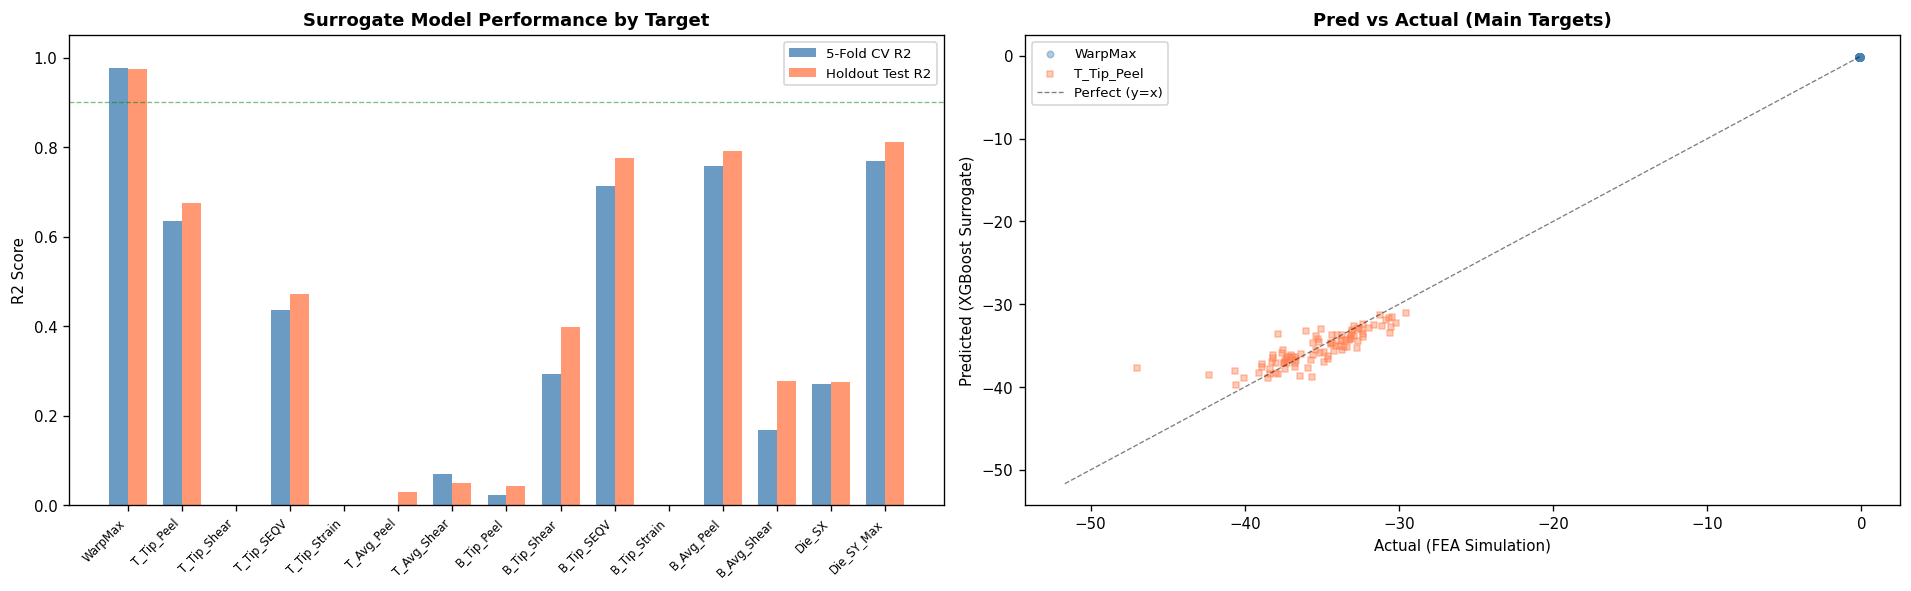

In [13]:
# == 4-3. 모델 성능 시각화 ==

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- (A) 변수별 R2 비교 바 차트 (CV vs Test) ---
ax = axes[0]
x_pos = np.arange(len(Y_COLUMNS))
width = 0.35

# CV R2 (파란색)과 Test R2 (주황색)을 나란히 표시
ax.bar(x_pos - width/2, [cv_scores[c] for c in Y_COLUMNS], width,
       label='5-Fold CV R2', color='steelblue', alpha=0.8)
ax.bar(x_pos + width/2, [test_scores[c] for c in Y_COLUMNS], width,
       label='Holdout Test R2', color='coral', alpha=0.8)

ax.set_xticks(x_pos)
ax.set_xticklabels(Y_COLUMNS, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('R2 Score')
ax.set_title('Surrogate Model Performance by Target', fontweight='bold')
ax.legend(fontsize=8)
ax.axhline(0.9, color='green', linewidth=0.8, linestyle='--', alpha=0.5)  # R2=0.9 기준선
ax.set_ylim(0, 1.05)

# --- (B) Pred vs Actual 산점도 (메인 타겟 2개) ---
ax = axes[1]
for y_col, color, marker in [('WarpMax', 'steelblue', 'o'), ('T_Tip_Peel', 'coral', 's')]:
    y_actual = Y_test[y_col].values
    y_pred = models[y_col].predict(X_test)
    ax.scatter(y_actual, y_pred, alpha=0.4, s=15, c=color, marker=marker, label=y_col)

# 완벽 예측선 (y=x) 표시
all_vals = np.concatenate([Y_test['WarpMax'].values, Y_test['T_Tip_Peel'].values])
lims = [all_vals.min() * 1.1, all_vals.max() * 1.1]
ax.plot(lims, lims, 'k--', linewidth=0.8, alpha=0.5, label='Perfect (y=x)')
ax.set_xlabel('Actual (FEA Simulation)')
ax.set_ylabel('Predicted (XGBoost Surrogate)')
ax.set_title('Pred vs Actual (Main Targets)', fontweight='bold')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

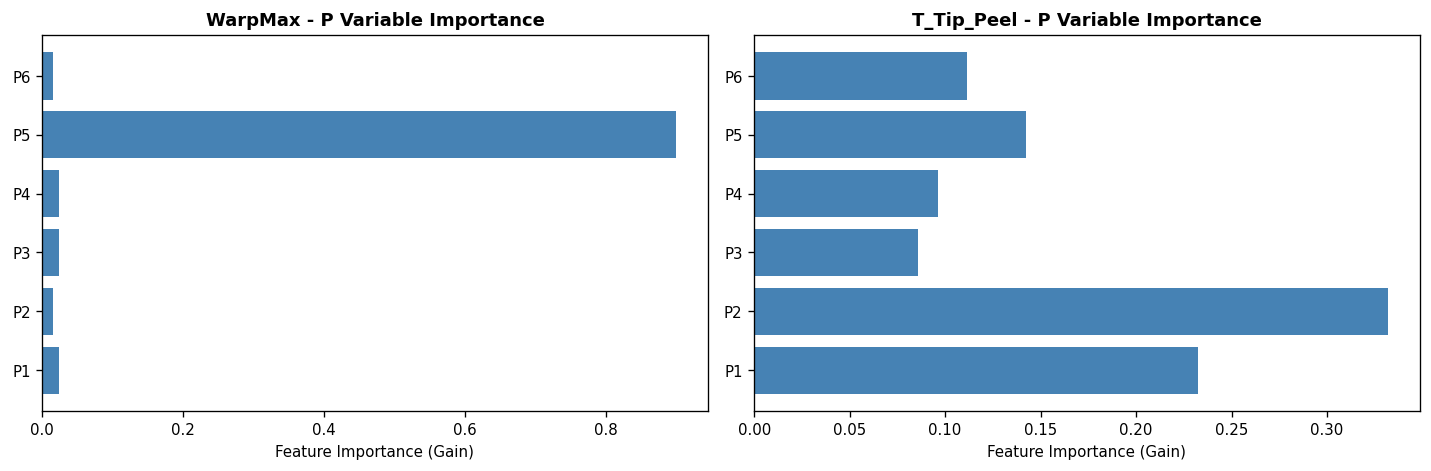

In [14]:
# == 4-4. Feature Importance (P1~P6 중 어떤 변수가 중요한지) ==
# 메인 타겟(WarpMax, T_Tip_Peel) 기준으로 각 두께 변수의 기여도 확인
# -> 어떤 층의 두께가 휨/박리에 가장 큰 영향을 주는지 파악

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_col in zip(axes, ['WarpMax', 'T_Tip_Peel']):
    importance = models[y_col].feature_importances_  # gain 기반 중요도
    ax.barh(['P1','P2','P3','P4','P5','P6'], importance, color='steelblue')
    ax.set_xlabel('Feature Importance (Gain)')
    ax.set_title(f'{y_col} - P Variable Importance', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 5. 몬테카를로 난수 생성 및 10만 개 가상 데이터 증강

학습된 XGBoost 대리 모델로 **10만 개의 가상 P1~P6 조합**에 대한 Y값을 예측합니다.

### 난수 생성 방식: Latin Hypercube Sampling (LHS)
- 단순 `np.random.uniform`보다 6차원 설계 공간을 **더 균일하게 커버**
- 각 차원을 N개 구간으로 분할 후 구간당 1개씩 배치 (층화 샘플링)
- 동일 샘플 수 대비 사각지대(dead zone) 없이 골고루 분포

In [15]:
# == 5-1. Latin Hypercube Sampling (LHS)으로 10만 개 P1~P6 생성 ==

N_VIRTUAL = 100_000  # 생성할 가상 데이터 수

def latin_hypercube_sampling(n_samples, n_dims, seed=42):
    """
    Latin Hypercube Sampling (LHS) 구현
    
    원리:
    - [0, 1] 범위를 n_samples개의 균등 구간으로 분할
    - 각 차원에서 한 구간당 정확히 하나의 샘플을 배치 (층화 샘플링)
    - 차원별로 독립적으로 셔플하여 조합
    
    Parameters:
        n_samples: 생성할 샘플 수
        n_dims: 차원 수 (변수 수)
        seed: 난수 시드
    Returns:
        (n_samples, n_dims) numpy 배열, 값 범위 [0, 1]
    """
    rng = np.random.RandomState(seed)
    result = np.zeros((n_samples, n_dims))
    
    for dim in range(n_dims):
        # 각 구간 내에서의 랜덤 오프셋 생성
        perms = rng.permutation(n_samples)  # 구간 순서 셔플
        # (구간 번호 + 랜덤 오프셋) / 총 구간 수 -> [0, 1] 범위로 정규화
        result[:, dim] = (perms + rng.uniform(size=n_samples)) / n_samples
    
    return result

# [0,1]^6 범위 LHS 생성
lhs_raw = latin_hypercube_sampling(N_VIRTUAL, n_dims=6, seed=SEED)

# 각 P 변수의 실제 min/max 바운더리로 스케일링
# 바운더리는 마스터 DOE 전체 1200개 기준 (생존 데이터가 아닌 원본 전체)
p_cols = ['P1','P2','P3','P4','P5','P6']
virtual_X_dict = {}

print(f'-- {N_VIRTUAL:,}개 가상 P1~P6 생성 (LHS) --')
print(f'{"변수":>5s} | {"Min":>8s} | {"Max":>8s}')
print('-' * 30)

for i, p in enumerate(p_cols):
    lo = df_master[p].min()   # 마스터 DOE 전체의 최솟값
    hi = df_master[p].max()   # 마스터 DOE 전체의 최댓값
    
    # [0,1] -> [min, max] 선형 변환
    virtual_X_dict[p] = lo + (hi - lo) * lhs_raw[:, i]
    print(f'{p:>5s} | {lo:8.4f} | {hi:8.4f}')

df_virtual_X = pd.DataFrame(virtual_X_dict)
print(f'\n{N_VIRTUAL:,}개 가상 P1~P6 조합 생성 완료')
display(df_virtual_X.describe().round(4))

-- 100,000개 가상 P1~P6 생성 (LHS) --
   변수 |      Min |      Max
------------------------------
   P1 |   0.8005 |   1.0998
   P2 |   0.0500 |   0.0899
   P3 |   0.6001 |   0.7198
   P4 |   0.1000 |   0.2994
   P5 |   1.2003 |   1.7997
   P6 |   0.0401 |   0.0800

100,000개 가상 P1~P6 조합 생성 완료


,P1,P2,P3,P4,P5,P6
count,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000
mean,0.9502,0.0699,0.6600,0.1997,1.5000,0.0600
std,0.0864,0.0115,0.0346,0.0576,0.1730,0.0115
min,0.8005,0.0500,0.6001,0.1000,1.2003,0.0401
25%,0.8753,0.0600,0.6300,0.1499,1.3502,0.0501
50%,0.9502,0.0700,0.6599,0.1997,1.5000,0.0600
75%,1.0250,0.0799,0.6899,0.2495,1.6498,0.0700
max,1.0998,0.0899,0.7198,0.2994,1.7997,0.0800


In [16]:
# == 5-2. 대리 모델로 10만 개 Y값 동시 예측 ==

print(f'학습된 XGBoost로 {N_VIRTUAL:,}개의 Y 값 예측 중...')
t_start = time.time()

virtual_Y_dict = {}
for y_col in Y_COLUMNS:
    # 각 타겟별로 학습된 개별 모델로 예측
    virtual_Y_dict[y_col] = models[y_col].predict(df_virtual_X)

df_virtual_Y = pd.DataFrame(virtual_Y_dict)

elapsed = time.time() - t_start
print(f'예측 완료! ({elapsed:.2f}초 소요)')

학습된 XGBoost로 100,000개의 Y 값 예측 중...
예측 완료! (0.33초 소요)


In [17]:
# == 5-3. 예측 결과 물리적 범위 검증 ==
# 대리 모델이 외삽(extrapolation)하여 비현실적인 값을 예측했는지 검증
# 실제 데이터 범위 +- 20% 마진을 허용 범위로 설정

print('=== 예측 데이터 물리적 범위 검증 ===')
print(f'{"변수":15s} | {"실제 Min":>12s} | {"실제 Max":>12s} | '
      f'{"예측 Min":>12s} | {"예측 Max":>12s} | 이탈률')
print('-' * 90)

outlier_flags = pd.Series(False, index=df_virtual_Y.index)

for y_col in Y_COLUMNS:
    actual_min = df_peaks[y_col].min()
    actual_max = df_peaks[y_col].max()
    pred_min = df_virtual_Y[y_col].min()
    pred_max = df_virtual_Y[y_col].max()
    
    # 실제 범위의 20% 마진을 허용 범위로 설정
    margin = (actual_max - actual_min) * 0.20
    safe_lo = actual_min - margin
    safe_hi = actual_max + margin
    
    # 허용 범위를 벗어나는 예측값 탐지
    out_mask = (df_virtual_Y[y_col] < safe_lo) | (df_virtual_Y[y_col] > safe_hi)
    outlier_flags = outlier_flags | out_mask
    n_out = out_mask.sum()
    pct = n_out / len(df_virtual_Y) * 100
    
    flag = '  <<' if pct > 5 else ''
    print(f'{y_col:15s} | {actual_min:12.4f} | {actual_max:12.4f} | '
          f'{pred_min:12.4f} | {pred_max:12.4f} | {pct:5.2f}%{flag}')

n_outlier = outlier_flags.sum()
print(f'\n범위 이탈 샘플 총합: {n_outlier:,}개 ({n_outlier/len(df_virtual_Y)*100:.2f}%)')
print('(이탈 샘플이 많으면 모델 과적합 또는 외삽 위험)')
print('-> Step 2 Gatekeeper 분류기에서 물리적으로 불안전한 조합은 추가 필터링 예정')

=== 예측 데이터 물리적 범위 검증 ===
변수              |       실제 Min |       실제 Max |       예측 Min |       예측 Max | 이탈률
------------------------------------------------------------------------------------------
WarpMax         |      -0.1728 |      -0.1025 |      -0.1687 |      -0.1089 |  0.00%
T_Tip_Peel      |     -47.2917 |     -28.7603 |     -42.6860 |     -28.8149 |  0.00%
T_Tip_Shear     |     -13.0566 |      10.6679 |      -7.7723 |      11.0826 |  0.00%
T_Tip_SEQV      |      30.9377 |      56.8349 |      31.2857 |      50.9045 |  0.00%
T_Tip_Strain    |       0.0028 |       0.0049 |       0.0036 |       0.0036 |  0.00%
T_Avg_Peel      |      -0.0317 |       0.1454 |      -0.0270 |       0.0968 |  0.00%
T_Avg_Shear     |      -5.2160 |      -2.4083 |      -4.4200 |      -2.3733 |  0.00%
B_Tip_Peel      |     -12.5674 |      11.6636 |     -11.0812 |       7.3398 |  0.00%
B_Tip_Shear     |      -6.0878 |      -1.6600 |      -4.8469 |      -1.7104 |  0.00%
B_Tip_SEQV      |      23.2101 |     

In [18]:
# == 5-4. 증강 데이터 병합 및 CSV 저장 ==

# X(입력: P1~P6)와 예측된 Y(출력: 15개 응력/변형 피크) 병합
df_augmented = pd.concat([df_virtual_X, df_virtual_Y], axis=1)

# 가상 데이터 식별용 ID 부여 (원본과 구분)
df_augmented.insert(0, 'Row_ID', [f'Virtual_{i+1}' for i in range(N_VIRTUAL)])

# CSV 저장
output_file = 'Augmented_100k_Data.csv'
df_augmented.to_csv(output_file, index=False)

print(f'=== 증강 데이터 저장 완료 ===')
print(f'파일명: {output_file}')
print(f'크기: {df_augmented.shape[0]:,}행 x {df_augmented.shape[1]}열')
print(f'컬럼: Row_ID + P1~P6 (6) + Y변수 ({len(Y_COLUMNS)}) = {1+6+len(Y_COLUMNS)}열')
print()
display(df_augmented.head())

=== 증강 데이터 저장 완료 ===
파일명: Augmented_100k_Data.csv
크기: 100,000행 x 22열
컬럼: Row_ID + P1~P6 (6) + Y변수 (15) = 22열



,Row_ID,P1,P2,P3,P4,P5,P6,WarpMax,T_Tip_Peel,T_Tip_Shear,...,T_Avg_Peel,T_Avg_Shear,B_Tip_Peel,B_Tip_Shear,B_Tip_SEQV,B_Tip_Strain,B_Avg_Peel,B_Avg_Shear,Die_SX,Die_SY_Max
0,Virtual_1,1.027135,0.087445,0.658718,0.231420,1.685991,0.052563,-0.115262,-34.916626,6.710666,...,0.002969,-2.998399,-5.756147,-2.119760,26.207052,0.001977,-0.013267,-2.966896,62.565830,-90.744438
1,Virtual_2,1.040493,0.076397,0.628455,0.214296,1.579394,0.077707,-0.123948,-34.512333,9.154263,...,0.012069,-2.768186,-6.306006,-2.407971,27.263506,0.001977,-0.020521,-2.833747,59.336079,-82.159698
2,Virtual_3,0.859955,0.086767,0.655392,0.189343,1.779187,0.066959,-0.111537,-33.456512,2.845052,...,0.010901,-2.906283,-6.800395,-2.562750,27.570383,0.001977,0.000066,-2.923249,61.756481,-82.859604
3,Virtual_4,1.030061,0.065772,0.626600,0.236199,1.400582,0.046464,-0.143422,-38.000134,5.024522,...,0.021872,-2.987523,-5.107958,-2.600349,28.259605,0.001977,-0.026689,-3.062769,63.431374,-96.159737
4,Virtual_5,1.078823,0.057586,0.608553,0.295215,1.325479,0.077874,-0.149712,-37.025928,9.546534,...,0.024988,-2.814260,-6.506069,-2.619918,27.872791,0.001977,-0.027082,-2.896110,62.141354,-82.216888


---
## 6. 증강 데이터 품질 검증 (Sanity Check)

증강된 10만 개 데이터의 분포가 원본 ~900개와 일관성이 있는지 시각적으로 검증합니다.

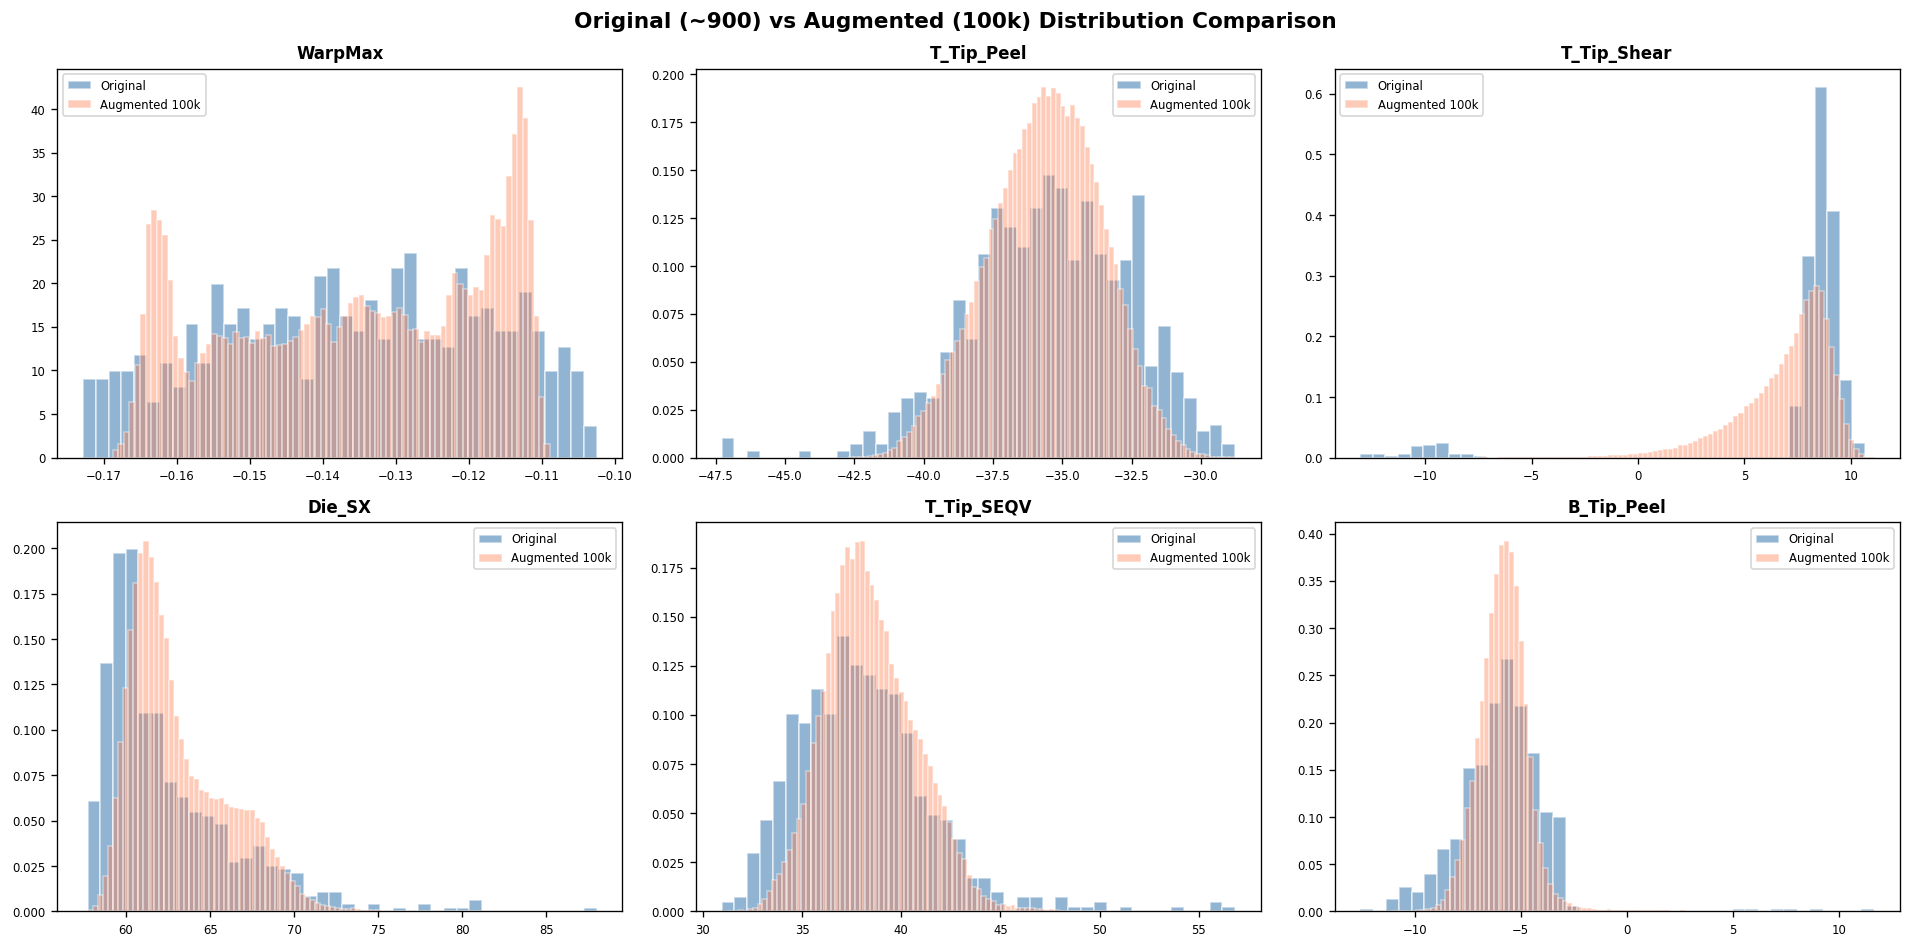

* 분포가 대체로 일치하면 -> 대리 모델이 원본 경향을 잘 학습한 것
* 분포가 크게 다르면 -> 과적합/외삽 위험 -> 하이퍼파라미터 재조정 필요


In [19]:
# == 6-1. 원본 vs 증강 분포 비교 (주요 6개 변수) ==

check_cols = ['WarpMax', 'T_Tip_Peel', 'T_Tip_Shear', 'Die_SX',
              'T_Tip_SEQV', 'B_Tip_Peel']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Original (~900) vs Augmented (100k) Distribution Comparison',
             fontsize=13, fontweight='bold')

for idx, y_col in enumerate(check_cols):
    ax = axes[idx // 3, idx % 3]
    
    # 원본 데이터 분포 (파란색 히스토그램)
    ax.hist(df_peaks[y_col], bins=40, density=True, alpha=0.6,
            color='steelblue', edgecolor='white', label='Original')
    
    # 증강 데이터 분포 (빨간색 히스토그램, 더 세밀한 bin)
    ax.hist(df_augmented[y_col], bins=80, density=True, alpha=0.4,
            color='coral', edgecolor='white', label='Augmented 100k')
    
    ax.set_title(y_col, fontweight='bold', fontsize=10)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

print('* 분포가 대체로 일치하면 -> 대리 모델이 원본 경향을 잘 학습한 것')
print('* 분포가 크게 다르면 -> 과적합/외삽 위험 -> 하이퍼파라미터 재조정 필요')

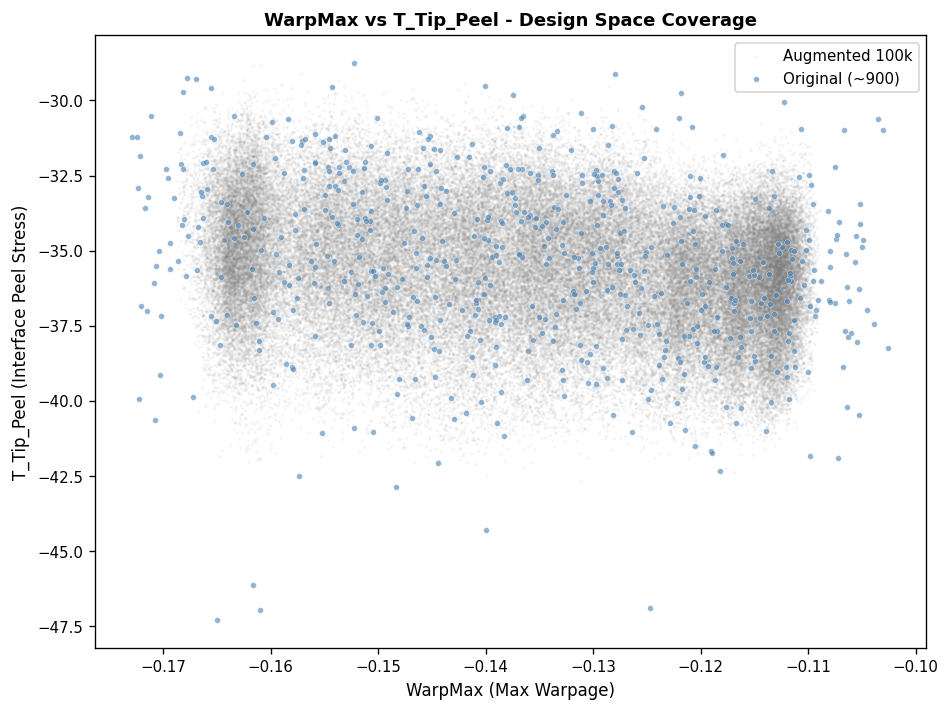

-> 이 2D 공간에서 좌측 하단(WarpMax 작고, T_Tip_Peel 작은)이 이상적인 설계
-> Step 3에서 파레토 프론티어(비지배 해 집합)를 추출할 영역


In [20]:
# == 6-2. 메인 타겟 2D 산점도 (WarpMax vs T_Tip_Peel) ==
# Step 3 파레토 프론티어에서 사용할 두 축의 공간 분포 확인

fig, ax = plt.subplots(figsize=(8, 6))

# 증강 데이터 (배경: 회색, 매우 투명하게)
ax.scatter(df_augmented['WarpMax'], df_augmented['T_Tip_Peel'],
           s=1, alpha=0.05, c='gray', label='Augmented 100k')

# 원본 데이터 (전경: 파란색, 선명하게)
ax.scatter(df_peaks['WarpMax'], df_peaks['T_Tip_Peel'],
           s=12, alpha=0.6, c='steelblue', edgecolors='white',
           linewidths=0.3, label='Original (~900)')

ax.set_xlabel('WarpMax (Max Warpage)', fontsize=10)
ax.set_ylabel('T_Tip_Peel (Interface Peel Stress)', fontsize=10)
ax.set_title('WarpMax vs T_Tip_Peel - Design Space Coverage', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('-> 이 2D 공간에서 좌측 하단(WarpMax 작고, T_Tip_Peel 작은)이 이상적인 설계')
print('-> Step 3에서 파레토 프론티어(비지배 해 집합)를 추출할 영역')

---
## Step 1 완료 요약

| 항목 | 결과 |
|------|------|
| 원본 생존 데이터 | ~900개 DP (1200 중 ~71%) |
| 추출 지표 | 15개 Y변수의 절댓값 Max Peak (부호 유지) |
| 대리 모델 | 타겟별 개별 XGBoost (Early Stopping + 5-Fold CV) |
| 증강 데이터 | **100,000개** (`Augmented_100k_Data.csv`) |
| 난수 생성 | Latin Hypercube Sampling (균등 공간 충전) |

### 다음 단계
-> **[Step 2: Gatekeeper 분류기]** 에서 증강된 10만 개 중 '물리적으로 파괴되는 조합'을 필터링합니다.